# 1. Load statements


In [11]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore', '.*do not.*', )
warnings.warn('Do not show this message')
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn import tree
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import balanced_accuracy_score
import ionifti



# 2. Load data

## 2.1 Filter NaNs

In [12]:
df=pd.read_csv('metadata/BreastDCEDL_metadata_min_crop.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2072 entries, 0 to 2071
Data columns (total 29 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pid             2072 non-null   object 
 1   pCR             1432 non-null   float64
 2   n_xy            2072 non-null   float64
 3   n_z             2072 non-null   float64
 4   n_times         2072 non-null   float64
 5   pre             2072 non-null   float64
 6   post_early      2072 non-null   float64
 7   post_late       2072 non-null   float64
 8   slice_thick     2072 non-null   float64
 9   xy_spacing      2072 non-null   float64
 10  mask_start      2072 non-null   float64
 11  mask_end        2072 non-null   float64
 12  sraw            2072 non-null   float64
 13  eraw            2072 non-null   float64
 14  scol            2072 non-null   float64
 15  ecol            2072 non-null   float64
 16  tum_vol         2071 non-null   float64
 17  age             2072 non-null   f

In [13]:
print("Original:", df.shape)

# 1. Filtrar cohortes
df = df[df["pid"].str.contains("ISPY2|ACRIN", regex=True)]
print("After cohort filter:", df.shape)

required_cols = ["pid", "pCR", "mask_start", "mask_end", "test"]
df = df.dropna(subset=required_cols)
print("After NaN filter:", df.shape)
df = df.reset_index(drop=True)


Original: (2072, 29)
After cohort filter: (982, 29)
After NaN filter: (982, 29)


In [14]:
df["pCR"] = df["pCR"].astype(int)
print("NaNs pCR:", df["pCR"].isna().sum())


NaNs pCR: 0


In [15]:
pids=[]
deb=1
for i,row in df.iterrows():

    if ionifti.get_all_nifti_acquisitions(row['pid']) is not None:
        pids.append(row['pid'])


['ACRIN-6698-102212_spy2_vis1_dce_aqc_0.nii.gz', 'ACRIN-6698-102212_spy2_vis1_dce_aqc_2.nii.gz', 'ACRIN-6698-102212_spy2_vis1_dce_aqc_6.nii.gz', 'ACRIN-6698-103939_spy2_vis1_dce_aqc_0.nii.gz', 'ACRIN-6698-103939_spy2_vis1_dce_aqc_2.nii.gz', 'ACRIN-6698-103939_spy2_vis1_dce_aqc_5.nii.gz', 'ACRIN-6698-104268_spy2_vis1_dce_aqc_0.nii.gz'] ACRIN-6698-102212
['ACRIN-6698-102212_spy2_vis1_dce_aqc_0.nii.gz', 'ACRIN-6698-102212_spy2_vis1_dce_aqc_2.nii.gz', 'ACRIN-6698-102212_spy2_vis1_dce_aqc_6.nii.gz']
['ACRIN-6698-102212_spy2_vis1_dce_aqc_0.nii.gz', 'ACRIN-6698-102212_spy2_vis1_dce_aqc_2.nii.gz', 'ACRIN-6698-102212_spy2_vis1_dce_aqc_6.nii.gz', 'ACRIN-6698-103939_spy2_vis1_dce_aqc_0.nii.gz', 'ACRIN-6698-103939_spy2_vis1_dce_aqc_2.nii.gz', 'ACRIN-6698-103939_spy2_vis1_dce_aqc_5.nii.gz', 'ACRIN-6698-104268_spy2_vis1_dce_aqc_0.nii.gz'] ACRIN-6698-103939
['ACRIN-6698-103939_spy2_vis1_dce_aqc_0.nii.gz', 'ACRIN-6698-103939_spy2_vis1_dce_aqc_2.nii.gz', 'ACRIN-6698-103939_spy2_vis1_dce_aqc_5.nii.gz']


# 3. Define features and load dataset


In [16]:
df.groupby('test').size()

test
0.0    784
1.0     99
2.0     99
dtype: int64

In [17]:
df.columns

Index(['pid', 'pCR', 'n_xy', 'n_z', 'n_times', 'pre', 'post_early',
       'post_late', 'slice_thick', 'xy_spacing', 'mask_start', 'mask_end',
       'sraw', 'eraw', 'scol', 'ecol', 'tum_vol', 'age', 'menopause',
       'race_white', 'race_black', 'HR', 'HER2', 'HR_HER2_STATUS', 'TripleNeg',
       'HER2pos', 'HRposHER2neg', 'dataset', 'test'],
      dtype='object')

In [18]:
df_train = df[df["test"] == 0]
df_val   = df[df["test"] == 2]
df_test  = df[df["test"] == 1]


In [19]:

features = [
    'pid', 'pCR', 'n_xy', 'n_z', 'n_times', 'pre', 'post_early',
       'post_late', 'slice_thick', 'xy_spacing', 'mask_start', 'mask_end',
       'sraw', 'eraw', 'scol', 'ecol', 'tum_vol', 'age', 'menopause',
       'race_white', 'race_black', 'HR', 'HER2', 'HR_HER2_STATUS', 'TripleNeg',
       'HER2pos', 'HRposHER2neg', 'dataset', 'test'
]

X = df[features]
y = df["pCR"]

X_train = df_train[features]
y_train = df_train["pCR"]

X_val   = df_val[features]
y_val   = df_val["pCR"]

X_test  = df_test[features]
y_test  = df_test["pCR"]

# 4. Models

## 4.1 Logistic Regression

Initialize and train model

In [20]:

# Instantiating model
clf_lr = LogisticRegression(random_state=42)

# Defining model parameters and a 3-fold cross-validation
params_lr = {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear', 'lbfgs'], 'max_iter': [1000]}

grid_search_cv_lr = GridSearchCV(clf_lr, params_lr, cv=3, verbose=1)



In [21]:
print("NaNs pCR:", X_train.isna().sum())


NaNs pCR: pid                0
pCR                0
n_xy               0
n_z                0
n_times            0
pre                0
post_early         0
post_late          0
slice_thick        0
xy_spacing         0
mask_start         0
mask_end           0
sraw               0
eraw               0
scol               0
ecol               0
tum_vol            0
age                0
menopause         30
race_white         0
race_black         0
HR                 0
HER2               0
HR_HER2_STATUS     0
TripleNeg          0
HER2pos            0
HRposHER2neg       0
dataset            0
test               0
dtype: int64


In [22]:
grid_search_cv_lr.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


ValueError: 
All the 30 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Ivón\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Ivón\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Ivón\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py", line 1191, in fit
    X, y = validate_data(
           ^^^^^^^^^^^^^^
  File "C:\Users\Ivón\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py", line 2919, in validate_data
    X, y = check_X_y(X, y, **check_params)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Ivón\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py", line 1314, in check_X_y
    X = check_array(
        ^^^^^^^^^^^^
  File "C:\Users\Ivón\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py", line 1022, in check_array
    array = _asarray_with_order(array, order=order, dtype=dtype, xp=xp)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Ivón\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\_array_api.py", line 878, in _asarray_with_order
    array = numpy.asarray(array, order=order, dtype=dtype)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Ivón\AppData\Roaming\Python\Python312\site-packages\pandas\core\generic.py", line 2171, in __array__
    arr = np.asarray(values, dtype=dtype)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ValueError: could not convert string to float: 'ISPY2-153327'

--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Ivón\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Ivón\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Ivón\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py", line 1191, in fit
    X, y = validate_data(
           ^^^^^^^^^^^^^^
  File "C:\Users\Ivón\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py", line 2919, in validate_data
    X, y = check_X_y(X, y, **check_params)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Ivón\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py", line 1314, in check_X_y
    X = check_array(
        ^^^^^^^^^^^^
  File "C:\Users\Ivón\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py", line 1022, in check_array
    array = _asarray_with_order(array, order=order, dtype=dtype, xp=xp)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Ivón\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\_array_api.py", line 878, in _asarray_with_order
    array = numpy.asarray(array, order=order, dtype=dtype)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Ivón\AppData\Roaming\Python\Python312\site-packages\pandas\core\generic.py", line 2171, in __array__
    arr = np.asarray(values, dtype=dtype)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ValueError: could not convert string to float: 'ACRIN-6698-103939'


In [ ]:
logistic_regression_train_accuracy = 100 * grid_search_cv_lr.best_score_  # Average performance on the training set (validation during GridSearchCV)

In [ ]:
y_pred = grid_search_cv_lr.predict(X_test)

In [ ]:
print("Logistic Regression Test set predictions:\n {}\n".format(y_pred))

Logistic Regression Test set predictions:
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1]



In [ ]:
logistic_regression_test_accuracy = 100 * balanced_accuracy_score(y_pred, y_test)  # Performance on the test set

In [ ]:
print("Logistic Regression Test set accuracy: {:.2f}%".format(logistic_regression_test_accuracy))

Logistic Regression Test set accuracy: 67.61%


## 4.2. Neural Network


In [ ]:
# Instantiating model
clf_nn = MLPClassifier(random_state=42)

# Defining model parameters and a 3-fold cross-validation
params_nn = {'hidden_layer_sizes': [(100,), (50, 50), (30, 30, 30)],
          'alpha': [0.0001, 0.001, 0.01],
          'max_iter': [1000]}

grid_search_cv_nn = GridSearchCV(clf_nn, params_nn, cv=3, verbose=1)

In [ ]:
grid_search_cv_nn.fit(X_train, y_train)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPClassifier(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.0001, 0.001, ...], 'hidden_layer_sizes': [(100,), (50, ...), ...], 'max_iter': [1000]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displaye

In [ ]:
nn_train_accuracy = 100 * grid_search_cv_nn.best_score_  # Average performance on the training set (validation during GridSearchCV)

In [ ]:
print('\n Neural Network model average performance in validation sets: {:.2f}%\n'.format(nn_train_accuracy))


 Neural Network model average performance in validation sets: 67.73%



In [ ]:
y_pred = grid_search_cv_nn.predict(X_test)

In [ ]:
print("Neural Network Test set predictions:\n {}\n".format(y_pred))

Neural Network Test set predictions:
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]



In [ ]:
nn_test_accuracy = 100 * balanced_accuracy_score(y_pred, y_test)  # Performance on the test set


In [ ]:
print("Neural Network Test set accuracy: {:.2f}%".format(nn_test_accuracy))

Neural Network Test set accuracy: 67.68%


## 4.3. Support Vector Machines (SVM)

In [ ]:
# Instantiating model
clf_svm = SVC(random_state=42)

# Defining model parameters and a 3-fold cross-validation
params_svm = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf'], 'gamma': ['scale', 'auto']}

grid_search_cv_svm = GridSearchCV(clf_svm, params_svm, cv=3, verbose=1)

In [ ]:
grid_search_cv_svm.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displ

In [ ]:
svm_train_accuracy = 100 * grid_search_cv_svm.best_score_  # Average performance on the training set (validation during GridSearchCV)

In [ ]:
print('\n SVM model average performance in validation sets: {:.2f}%\n'.format(svm_train_accuracy))


 SVM model average performance in validation sets: 67.86%



In [ ]:
y_pred = grid_search_cv_svm.predict(X_test)

In [ ]:
print("SVM Test set predictions:\n {}\n".format(y_pred))

SVM Test set predictions:
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]



In [ ]:
svm_test_accuracy = 100 * balanced_accuracy_score(y_pred, y_test)  # Performance on the test set

In [ ]:
print("SVM Test set accuracy: {:.2f}%".format(svm_test_accuracy))

SVM Test set accuracy: 67.68%


## 4.4. Random Forests

In [ ]:
# Instantiating model
clf_rf = RandomForestClassifier(random_state=42)

# Defining model parameters and a 3-fold cross-validation
params_rf = {'n_estimators': [10, 50, 100, 200], 'max_depth': [None, 10, 20, 30]}

grid_search_cv_rf = GridSearchCV(clf_rf, params_rf, cv=3, verbose=1)

In [ ]:
grid_search_cv_rf.fit(X_train, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'n_estimators': [10, 50, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;-

In [ ]:
random_forest_train_accuracy = 100 * grid_search_cv_rf.best_score_  # Average performance on the training set (validation during GridSearchCV)

In [ ]:
print('\n Random Forest  model average performance in validation sets: {:.2f}%\n'.format(random_forest_train_accuracy))


 Random Forest  model average performance in validation sets: 66.71%



In [ ]:
y_pred = grid_search_cv_rf.predict(X_test)

In [ ]:
print("Random Forest  Test set predictions:\n {}\n".format(y_pred))

Random Forest  Test set predictions:
 [1 0 1 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0]



In [ ]:
random_forest_test_accuracy = 100 * balanced_accuracy_score(y_pred, y_test)  # Performance on the test set

In [ ]:
print("Random Forest  Test set accuracy: {:.2f}%".format(random_forest_test_accuracy))

Random Forest  Test set accuracy: 64.20%


## 4.5. Decision Tree

In [ ]:
#instantiating the model
clf_decision_tree = tree.DecisionTreeClassifier(random_state=42)

params_decision_tree = {'max_leaf_nodes': list(range(2, 100)), 'min_samples_split': [2, 3, 4]}
grid_search_cv_decision_tree = GridSearchCV(clf_decision_tree, params_decision_tree, cv=3, verbose=1)



In [ ]:
grid_search_cv_decision_tree.fit(X_train, y_train)

Fitting 3 folds for each of 294 candidates, totalling 882 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_leaf_nodes': [2, 3, ...], 'min_samples_split': [2, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also display

In [ ]:
decision_tree_train_accuracy = 100 * grid_search_cv_decision_tree.best_score_  # Average performance on the training set (validation during GridSearchCV)

In [ ]:
print('\n Decision Tree average performance in validation sets: {:.2f}%\n'.format(decision_tree_train_accuracy))


 Decision Tree average performance in validation sets: 70.03%



In [ ]:
y_pred = grid_search_cv_decision_tree.predict(X_test)

In [ ]:
print("Decision Tree Test set predictions:\n {}\n".format(y_pred))

Decision Tree Test set predictions:
 [0 0 1 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 1
 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 1]



In [ ]:
decision_tree_test_accuracy = 100 * balanced_accuracy_score(y_pred, y_test)  # Performance on the test set

In [ ]:
print("Decision Tree Test set accuracy: {:.2f}%".format(decision_tree_test_accuracy))

Decision Tree Test set accuracy: 62.57%


## 4.6. KNeighborsClassifier

In [ ]:
#yourcode
from sklearn.neighbors import KNeighborsClassifier

# Instantiating model
clf_knn = KNeighborsClassifier()

# Defining model parameters and a 3-fold cross-validation
params_knn = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}

grid_search_cv_knn = GridSearchCV(clf_knn, params_knn, cv=3, verbose=1)


In [ ]:
grid_search_cv_knn.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 :

In [ ]:
knn_train_accuracy = 100 * grid_search_cv_knn.best_score_  # Average performance on the training set (validation during GridSearchCV)

In [ ]:
print('\n KNN  model average performance in validation sets: {:.2f}%\n'.format(knn_train_accuracy))


 KNN  model average performance in validation sets: 63.78%



In [ ]:
y_pred = grid_search_cv_knn.predict(X_test)

In [ ]:
knn_test_accuracy = 100 * balanced_accuracy_score(y_pred, y_test)  # Performance on the test set

In [ ]:
print("KNN  Test set accuracy: {:.2f}%".format(knn_test_accuracy))

KNN  Test set accuracy: 54.27%


# 5. Model Comparison

In [ ]:
# Creating a DataFrame with the results
#yourcode
accuracies = pd.DataFrame({
    'Model': ['Neural Network', 'Decision Tree', 'SVM', 'Logistic Regression', 'KNN', 'Random Forest'],
    'Train Accuracy (%)': [nn_train_accuracy, decision_tree_train_accuracy, svm_train_accuracy, logistic_regression_train_accuracy, knn_train_accuracy, random_forest_train_accuracy],
    'Test Accuracy (%)': [nn_test_accuracy, decision_tree_test_accuracy, svm_test_accuracy, logistic_regression_test_accuracy, knn_test_accuracy, random_forest_test_accuracy]
})
# Sorting the results by test accuracy in descending order for better comparison
#yourcode
accuracies.sort_values(by='Test Accuracy (%)', ascending=False, inplace=True)

# Resetting the DataFrame index for better visualization
#yourcode
accuracies.reset_index(drop=True, inplace=True)

# Printing the table
#yourcode
print(accuracies)


                 Model  Train Accuracy (%)  Test Accuracy (%)
0       Neural Network           67.729324          67.676768
1                  SVM           67.857038          67.676768
2  Logistic Regression           70.788122          67.613636
3        Random Forest           66.710538          64.197531
4        Decision Tree           70.025250          62.565789
5                  KNN           63.777017          54.269663


# Improving model with PCA

In [ ]:
from sklearn.metrics import accuracy_score

# Training a classifier without applying PCA
clf = LogisticRegression(max_iter=500, C=0.1)  # regularización


In [ ]:

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(f"Accuracy without PCA: {accuracy_score(y_test, y_pred):.2f}")

Accuracy without PCA: 0.72


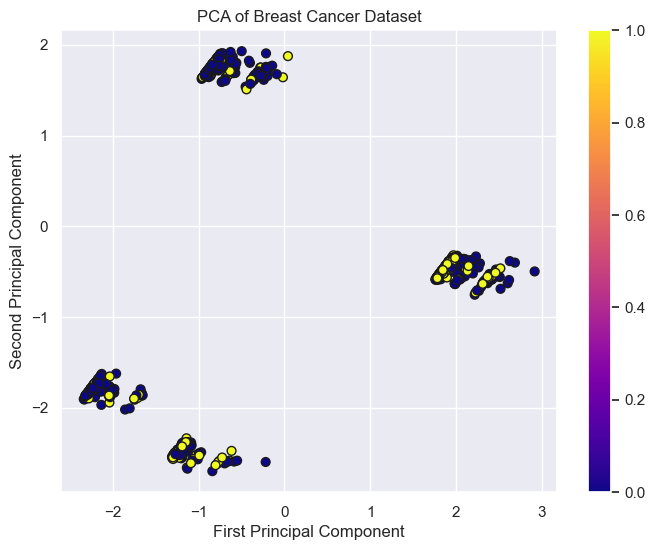

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Standardize the data before applying PCA. PCA is affected by scale, so you need to scale the features in your data before applying PCA.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Applying PCA to reduce to 2 components.
# Apply PCA to reduce the data to two dimensions and visualize the result. This step will help you see if the data points are separable into their respective classes.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualization of the data in the first two principal components
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='plasma', edgecolor='k', s=40)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA of Breast Cancer Dataset')
plt.colorbar()
plt.show()

In [ ]:
X_train_pca = df_train[features]
X_test_pca  = df_test[features]

In [ ]:

# Training a classifier with PCA-transformed data
clf.fit(X_train_pca, y_train)
y_pred_pca = clf.predict(X_test_pca)
print(f"Accuracy with PCA: {accuracy_score(y_test, y_pred_pca):.2f}")

Accuracy with PCA: 0.72
